In [1]:
import pandas as pd
from sklearn.preprocessing import RobustScaler

# Chargement du fichier
df = pd.read_csv('creditcard.csv')
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [2]:
# On utilise // pour avoir un nombre entier d'heures
# On utilise % 24 pour que si on dépasse 24h (86400s), on recommence à 0
df['Hour'] = (df['Time'] // 3600) % 24

# On vérifie maintenant
print("Exemple de conversion propre :")
print(df[['Time', 'Hour']].head(10))

Exemple de conversion propre :
   Time  Hour
0   0.0   0.0
1   0.0   0.0
2   1.0   0.0
3   1.0   0.0
4   2.0   0.0
5   2.0   0.0
6   4.0   0.0
7   7.0   0.0
8   7.0   0.0
9   9.0   0.0


In [3]:
# On prépare notre outil de mise à l'échelle
scaler = RobustScaler()

# On crée une nouvelle colonne 'Amount_Scaled' avec les prix transformés
df['Amount_Scaled'] = scaler.fit_transform(df[['Amount']])

# On supprime les anciennes colonnes 'Time' et 'Amount' car on a les nouvelles versions propres
df = df.drop(['Time', 'Amount'], axis=1)

In [4]:
df.head()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V22,V23,V24,V25,V26,V27,V28,Class,Hour,Amount_Scaled
0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,...,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,0,0.0,1.783274
1,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,...,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,0,0.0,-0.269825
2,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,...,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,0,0.0,4.983721
3,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,...,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,0,0.0,1.418291
4,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,...,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,0,0.0,0.670579


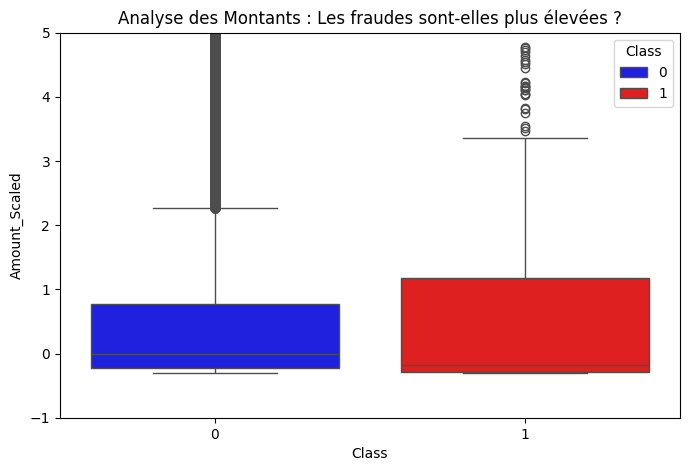

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# --- GRAPHIQUE : LE MONTANT ---
plt.figure(figsize=(8, 5))
# On compare les montants scalés entre Normal (0) et Fraude (1)
sns.boxplot(x='Class', y='Amount_Scaled', hue='Class', data=df, palette={0: 'blue', 1: 'red'})
# On limite l'axe Y pour mieux voir le "coeur" de la boîte (zoom)
plt.ylim(-1, 5) 
plt.title('Analyse des Montants : Les fraudes sont-elles plus élevées ?')
plt.show()

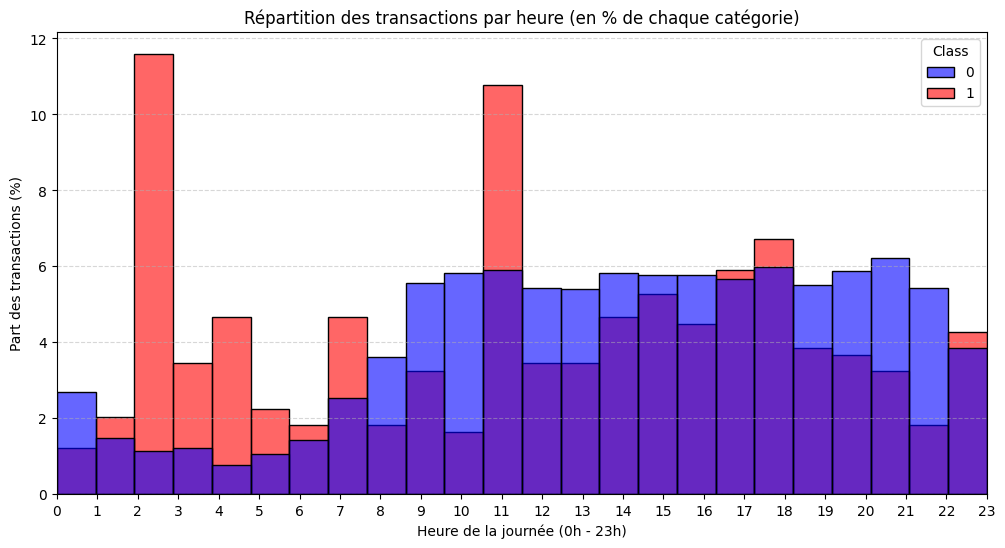

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))

# stat="percent" : affiche directement le % (0 à 100)
# common_norm=False : calcule le % par rapport au total de CHAQUE couleur
sns.histplot(data=df, x='Hour', hue='Class', bins=24, 
             stat="percent", common_norm=False, element="bars", 
             palette=['blue', 'red'], alpha=0.6)

# On bloque l'axe X strictement sur la réalité
plt.xlim(0, 23)
plt.xticks(range(0, 24))

plt.title('Répartition des transactions par heure (en % de chaque catégorie)')
plt.xlabel('Heure de la journée (0h - 23h)')
plt.ylabel('Part des transactions (%)')
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# 1. On sépare les caractéristiques (X) de la réponse à deviner (y)
X = df.drop('Class', axis=1) # Tout sauf la colonne Class
y = df['Class']              # Uniquement la colonne Class

# 2. On divise en 80% entraînement et 20% test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 3. On crée l'IA (La Forêt Aléatoire)
# n_estimators=100 : on utilise 100 petits arbres de décision
# random_state=42 : pour que tu aies les mêmes résultats que moi
model = RandomForestClassifier(n_estimators=100, random_state=42)

# 4. L'ENTRAÎNEMENT (L'ordinateur étudie les données)
print("Entraînement en cours... (cela peut prendrcape 1 minute)")
model.fit(X_train, y_train)

print("✅ IA entraînée avec succès !")

import joblib
# On enregistre le modèle dans un fichier 'modele_fraude.pkl'
joblib.dump(model, 'modele_fraude.pkl')
print("Modèle sauvegardé !")

Entraînement en cours... (cela peut prendre 1 minute)
✅ IA entraînée avec succès !
Modèle sauvegardé !


--- RAPPORT DE CLASSIFICATION ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.94      0.83      0.88        98

    accuracy                           1.00     56962
   macro avg       0.97      0.91      0.94     56962
weighted avg       1.00      1.00      1.00     56962



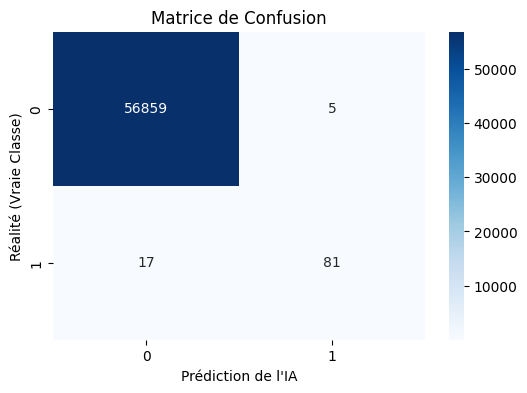

In [8]:
# 1. L'IA fait ses prédictions sur les données de test
y_pred = model.predict(X_test)

# 2. On affiche le rapport de performance
print("--- RAPPORT DE CLASSIFICATION ---")
print(classification_report(y_test, y_pred))

# 3. On affiche la matrice de confusion pour voir les erreurs
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title('Matrice de Confusion')
plt.xlabel('Prédiction de l\'IA')
plt.ylabel('Réalité (Vraie Classe)')
plt.show()

In [9]:
#Modèle simple pour la simulation manuelle :

features_simples = ['Hour', 'Amount_Scaled']
X_s = df[features_simples]
y_s = df['Class']

X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(X_s, y_s, test_size=0.2, random_state=42, stratify=y_s)

model_simple = RandomForestClassifier(n_estimators=100, random_state=42)
model_simple.fit(X_train_s, y_train_s)

# On sauvegarde le 2ème modèle
joblib.dump(model_simple, 'modele_simple.pkl')
print("✅ Modèle SIMPLE sauvegardé pour la simulation !")

✅ Modèle SIMPLE sauvegardé pour la simulation !


📊 PERFORMANCE DU MODÈLE SIMPLIFIÉ (Hour + Amount uniquement)
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.15      0.04      0.06        98

    accuracy                           1.00     56962
   macro avg       0.57      0.52      0.53     56962
weighted avg       1.00      1.00      1.00     56962



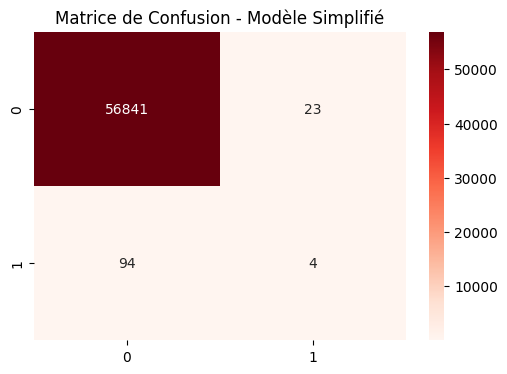

In [10]:
#Evaluation du modèle simple
# --- 1. PRÉDICTION ---
y_pred_simple = model_simple.predict(X_test_s)

# --- 2. RAPPORT DE PERFORMANCE ---
print("📊 PERFORMANCE DU MODÈLE SIMPLIFIÉ (Hour + Amount uniquement)")
print(classification_report(y_test_s, y_pred_simple))

# --- 3. MATRICE DE CONFUSION ---
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test_s, y_pred_simple), annot=True, fmt='d', cmap='Reds')
plt.title("Matrice de Confusion - Modèle Simplifié")
plt.show()